Import needed libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
from torchvision.models import mobilenet_v2
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign, box_iou, nms
from PIL import Image
import numpy as np
import random
from collections import defaultdict

Extract file

In [3]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/LSVH.zip", "r") as zip_ref:
    zip_ref.extractall("data")

Storing the images

In [4]:
import os

images_dir = "/content/data/LSVH/images"
labels_dir = "/content/data/LSVH/labels"

image_paths = []
label_paths = []

for fname in sorted(os.listdir(images_dir)):
    if fname.endswith((".jpg", ".jpeg")):
        img_path = os.path.join(images_dir, fname)
        lbl_path = os.path.join(labels_dir, fname.replace(".jpg", ".txt"))

        if os.path.exists(lbl_path):
            image_paths.append(img_path)
            label_paths.append(lbl_path)
print(len(image_paths))
print(len(label_paths))

14388
14388


Creating functions for ploting images

In [ ]:
import cv2

def draw_image(img_path, lbl_path, class_names=None):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(lbl_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 8:
            continue

        cls = int(parts[0])
        x1 = int(float(parts[4]))
        y1 = int(float(parts[5]))
        x2 = int(float(parts[6]))
        y2 = int(float(parts[7]))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = class_names[cls] if class_names else str(cls)
        cv2.putText(img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return img

In [6]:
import matplotlib.pyplot as plt

def show_images(image_paths, label_paths, class_names=None, n_cols=3):
    n_images = len(image_paths)
    n_rows = (n_images + n_cols - 1) // n_cols

    plt.figure(figsize=(5 * n_cols, 5 * n_rows))

    for i, (img_path, lbl_path) in enumerate(zip(image_paths, label_paths)):
        img = draw_image(img_path, lbl_path, class_names)
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Show a random Image ( whit don't care class )

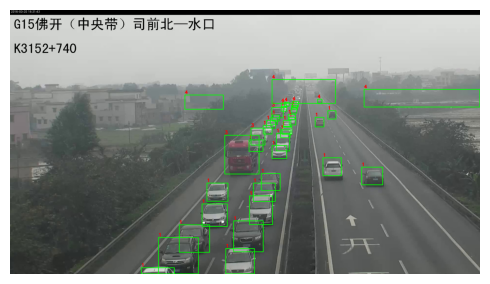

In [7]:
show_images([image_paths[100]] , [label_paths[100]] , n_cols=1)

Removing the don't care classes

In [ ]:
import os
import shutil

filtered_images_dir = "/content/data/LSVH/new/images"
filtered_labels_dir = "/content/data/LSVH/new/labels"
os.makedirs(filtered_images_dir, exist_ok=True)
os.makedirs(filtered_labels_dir, exist_ok=True)
deleted = []

for img_path, lbl_path in zip(image_paths, label_paths):
    with open(lbl_path, "r") as f:
        lines = f.readlines()

    filtered_lines = [line for line in lines if int(line.strip().split()[0]) in [1, 2, 3]]

    if len(filtered_lines) == 0:
        deleted.append((img_path , lbl_path))
        continue  

    base_name = os.path.basename(lbl_path)
    new_label_path = os.path.join(filtered_labels_dir, base_name)
    with open(new_label_path, "w") as f:
        f.writelines(filtered_lines)

    base_name_img = os.path.basename(img_path)
    new_img_path = os.path.join(filtered_images_dir, base_name_img)
    shutil.copy(img_path, new_img_path)


In [9]:
import os

images_dir = "/content/data/LSVH/new/images"
labels_dir = "/content/data/LSVH/new/labels"

new_image_paths = []
new_label_paths = []

for fname in sorted(os.listdir(images_dir)):
    if fname.endswith((".jpg", ".jpeg")):
        img_path = os.path.join(images_dir, fname)
        lbl_path = os.path.join(labels_dir, fname.replace(".jpg", ".txt"))

        if os.path.exists(lbl_path):
            new_image_paths.append(img_path)
            new_label_paths.append(lbl_path)
print(len(new_image_paths))
print(len(new_label_paths))

13938
13938


Show some random images for report

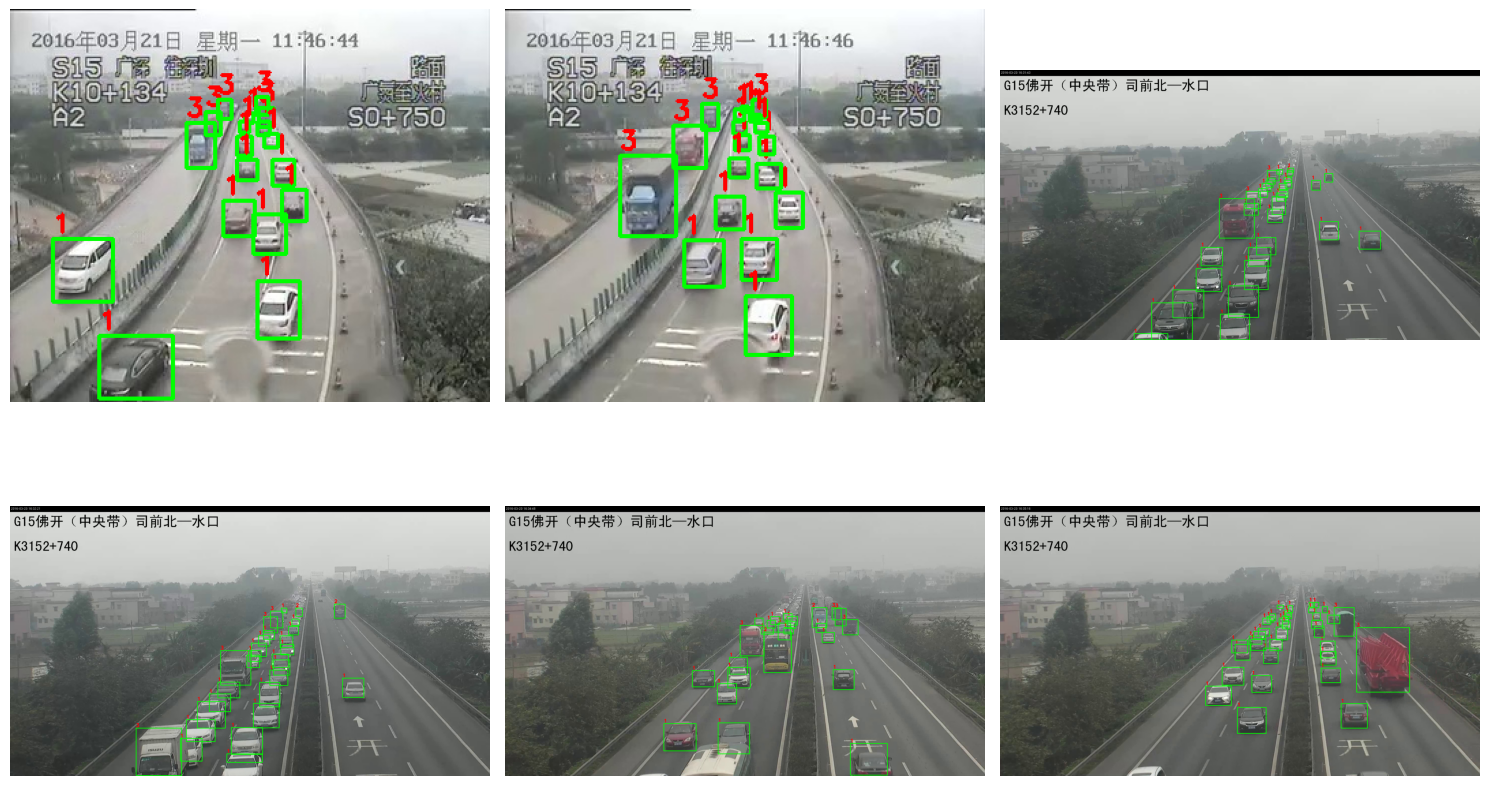

In [10]:
show_images([new_image_paths[1] , new_image_paths[10] , new_image_paths[100] ,
                  new_image_paths[500] , new_image_paths[1000], new_image_paths[1300]] ,
                  [new_label_paths[1] , new_label_paths[10] , new_label_paths[100] ,
                   new_label_paths[500] , new_label_paths[1000] , new_label_paths[1300]])

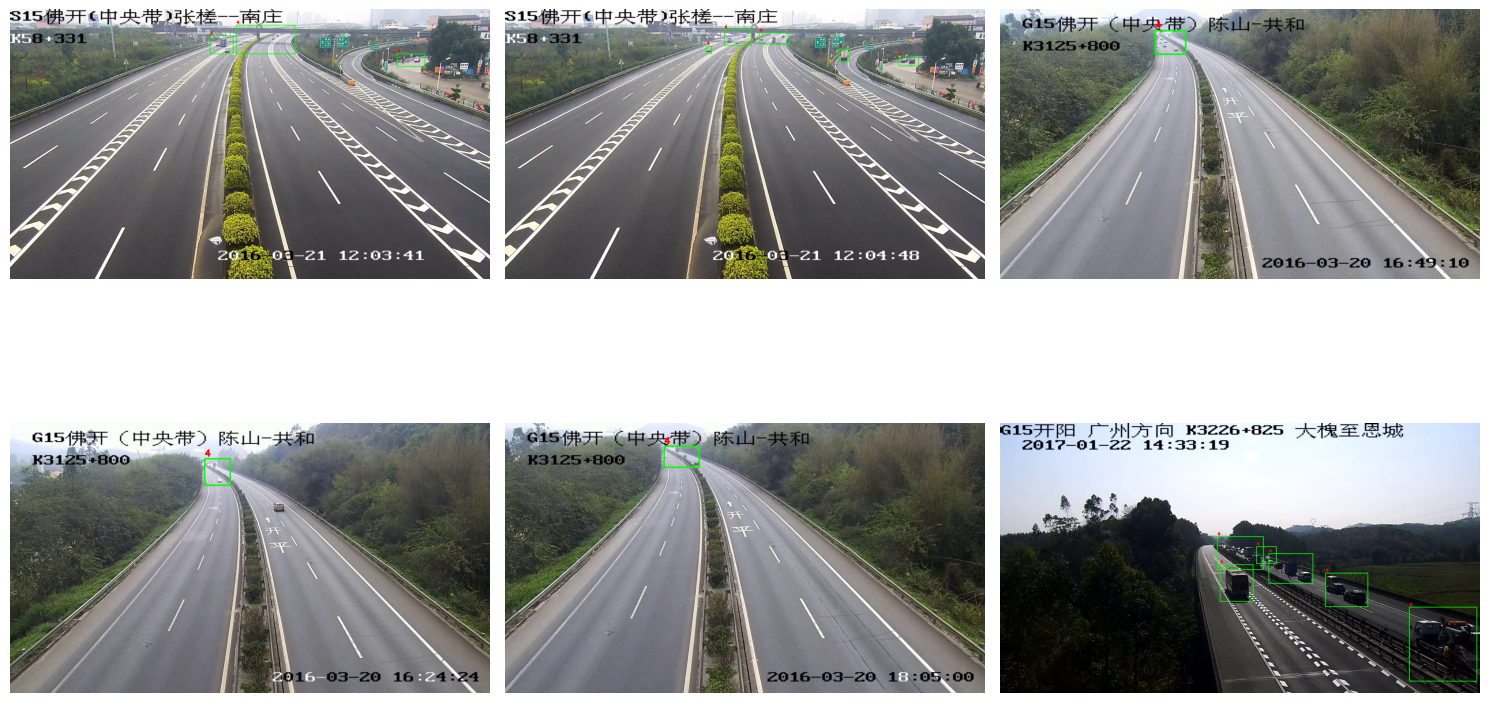

In [11]:
show_images([deleted[1][0] , deleted[10][0] , deleted[100][0] ,
                  deleted[200][0] , deleted[300][0], deleted[400][0]] ,
                  [deleted[1][1] , deleted[10][1] , deleted[100][1] ,
                   deleted[200][1] , deleted[300][1] , deleted[400][1]])

Creating the train and test dataset from text files

In [ ]:
import os

images_dir = "/content/data/LSVH/new/images"
labels_dir = "/content/data/LSVH/new/labels"

train_txt = "/content/data/LSVH/train.txt"
test_txt = "/content/data/LSVH/test.txt"

with open(train_txt, "r") as f:
    train_names = set(line.strip() for line in f.readlines())

with open(test_txt, "r") as f:
    test_names = set(line.strip() for line in f.readlines())

all_images = [f for f in os.listdir(images_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

train_images, train_labels = [], []
test_images, test_labels = [], []

for img_name in all_images:
    name_no_ext = os.path.splitext(img_name)[0]  
    img_path = os.path.join(images_dir, img_name)
    lbl_path = os.path.join(labels_dir, name_no_ext + ".txt")  

    if name_no_ext in train_names:
        train_images.append(img_path)
        train_labels.append(lbl_path)
    elif name_no_ext in test_names:
        test_images.append(img_path)
        test_labels.append(lbl_path)

print(f"Train images: {len(train_images)}, Test images: {len(test_images)}")


Train images: 9701, Test images: 4237


<h2> Building the Faster-RCNN model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

define helper function for creating datasets

In [14]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

Soft NMS function

In [ ]:
def soft_nms(boxes, scores, sigma=0.5, score_thresh=0.001):
    boxes = boxes.clone()
    scores = scores.clone()
    keep = []

    while scores.numel() > 0:
        max_idx = torch.argmax(scores)
        max_box = boxes[max_idx]
        max_score = scores[max_idx]
        keep.append(max_idx.item())

        boxes = torch.cat([boxes[:max_idx], boxes[max_idx+1:]])
        scores = torch.cat([scores[:max_idx], scores[max_idx+1:]])

        if scores.numel() == 0:
            break

        ious = box_iou(max_box.unsqueeze(0), boxes).squeeze(0)
        scores *= torch.exp(-(ious * ious) / sigma)

        keep_mask = scores > score_thresh
        boxes = boxes[keep_mask]
        scores = scores[keep_mask]

    return keep

RPN with soft-nms function

In [16]:
from torchvision.models.detection.rpn import RegionProposalNetwork

class RPNWithSoftNMS(RegionProposalNetwork):
    def filter_proposals(
        self,
        proposals,
        objectness,
        image_shapes,
        num_anchors_per_level
    ):
        final_boxes = []
        final_scores = []

        for boxes, scores in zip(proposals, objectness):
            scores = scores.sigmoid()

            keep = soft_nms(
                boxes,
                scores,
                sigma=0.5,
                score_thresh=0.001
            )

            final_boxes.append(boxes[keep])
            final_scores.append(scores[keep])

        return final_boxes, final_scores


In [17]:
def build_model(num_classes=4, freeze_backbone=True):
    backbone = mobilenet_v2(weights='IMAGENET1K_V1').features
    backbone.out_channels = 1280

    if freeze_backbone:
        for p in backbone.parameters():
            p.requires_grad = False

    anchor_gen = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    roi_pool = MultiScaleRoIAlign(['0'], 7, 2)

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_gen,
        box_roi_pool=roi_pool
    )

    return model


Choosing the images with under 10 target for training

In [18]:
def filter_dataset(dataset, max_targets=10):
  valid_indices = []
  for i in range(len(dataset)):
    _, target = dataset[i]
    if len(target['boxes']) < max_targets:
      valid_indices.append(i)
  return valid_indices

Choosing random samples for each epoch

In [27]:
def sample_indices(indices, train_ratio=0.2, val_ratio=0.1):
  random.shuffle(indices)
  n = len(indices)
  t_end = int(train_ratio * n)
  v_end = t_end + int(val_ratio * n)
  return indices[:t_end], indices[t_end:v_end]

Creating a function for compute mAP@50

In [ ]:
@torch.no_grad()

def compute_map50(model, loader, device, use_soft_nms=True):
    model.eval()
    aps = []

    for images, targets in loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            if len(tgt['boxes']) == 0 or len(out['boxes']) == 0:
                continue

            boxes = out['boxes'].cpu()
            scores = out['scores'].cpu()

            if use_soft_nms:
                keep = soft_nms(boxes, scores, sigma=0.5, score_thresh=0.001)
                boxes = boxes[keep]
            else:
                keep = nms(boxes, scores, iou_threshold=0.5)
                boxes = boxes[keep]

            if boxes.numel() == 0:
                continue

            ious = box_iou(boxes, tgt['boxes'])
            max_iou, _ = ious.max(dim=1)

            tp = (max_iou > 0.5).float().sum()
            fp = (max_iou <= 0.5).float().sum()

            aps.append((tp / (tp + fp + 1e-6)).item())

    return float(np.mean(aps)) if aps else 0.0

<h3> Creating the main train loop

In [30]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [35]:
def train_model(train_dataset, test_dataset, device, epochs=20, batch_size=8):

    model = build_model(num_classes=4, freeze_backbone=True)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"All Parameters : {total_params:,}")

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable Parameters : {trainable_params:,}")

    from torchvision.models.detection.transform import GeneralizedRCNNTransform

    model.transform = GeneralizedRCNNTransform(
        min_size=400,
        max_size=600,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225]
    )
    model.to(device)


    optimizer = optim.Adam([
        {'params': model.backbone.parameters(), 'lr': 1e-5},
        {'params': model.rpn.parameters(), 'lr': 1e-4},
        {'params': model.roi_heads.parameters(), 'lr': 1e-4},
    ], weight_decay=1e-4)

    history = defaultdict(list)

    for epoch in range(epochs):
        if epoch == 10:
            for p in model.backbone.parameters():
                p.requires_grad = True

        idx = list(range(len(train_dataset)))
        random.shuffle(idx)

        n_train = int(0.4 * len(idx))
        n_val = int(0.1 * len(idx))

        train_idx = idx[:n_train]
        val_idx = idx[n_train:n_train+n_val]

        train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size,
                                  shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(Subset(train_dataset, val_idx), batch_size,
                                shuffle=False, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size,
                                 shuffle=False, collate_fn=collate_fn)

        loss = train_one_epoch(model, train_loader, optimizer, device)
        history['loss'].append(loss)

        for g in optimizer.param_groups:
            g['lr'] *= (1 - 0.0005)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

        if (epoch + 1) % 10 == 0:
            val_map = compute_map50(model, val_loader, device)
            history['val_map'].append(val_map)
            print(f"mAP@50 | Val: {val_map:.4f}")

    return model, history

In [36]:
class DetectionDataset(Dataset):
    def __init__(self, image_paths, label_paths, transforms=None, max_targets=10):
        self.transforms = transforms
        self.max_targets = max_targets

        assert len(image_paths) == len(label_paths)

        self.samples = []
        for img_p, lbl_p in zip(image_paths, label_paths):
            boxes, labels = self._read_label(lbl_p)
            if 0 < len(boxes) < max_targets:
                self.samples.append((img_p, lbl_p))

    def _read_label(self, label_path):
        boxes, labels = [], []
        with open(label_path, 'r') as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 8:
                    continue
                cls = int(p[0])
                xmin, ymin, xmax, ymax = map(float, p[4:8])
                if xmax > xmin and ymax > ymin:
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(cls)
        return boxes, labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]
        img = Image.open(img_path).convert('RGB')

        boxes, labels = self._read_label(lbl_path)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels
        }

        if self.transforms:
            img = self.transforms(img)
        else:
            img = torchvision.transforms.functional.to_tensor(img)

        return img, target

Creating the dataset

In [37]:
train_dataset = DetectionDataset(train_images, train_labels)
test_dataset  = DetectionDataset(test_images, test_labels)


Training time :D

In [38]:
model, history = train_model(train_dataset, test_dataset, device)


All Parameters : 82,363,231
Trainable Parameters : 80,139,359
Epoch 1/20 | Loss: 0.1456
Epoch 2/20 | Loss: 0.1183
Epoch 3/20 | Loss: 0.1170
Epoch 4/20 | Loss: 0.1169
Epoch 5/20 | Loss: 0.1184
Epoch 6/20 | Loss: 0.1175
Epoch 7/20 | Loss: 0.1158
Epoch 8/20 | Loss: 0.1162
Epoch 9/20 | Loss: 0.1151
Epoch 10/20 | Loss: 0.1122
mAP@50 | Val: 0.3326
Epoch 11/20 | Loss: 0.1129
Epoch 12/20 | Loss: 0.1095
Epoch 13/20 | Loss: 0.1054
Epoch 14/20 | Loss: 0.1023
Epoch 15/20 | Loss: 0.1001
Epoch 16/20 | Loss: 0.0976
Epoch 17/20 | Loss: 0.0948
Epoch 18/20 | Loss: 0.0959
Epoch 19/20 | Loss: 0.0926
Epoch 20/20 | Loss: 0.0906
mAP@50 | Val: 0.7064


Plotting the results

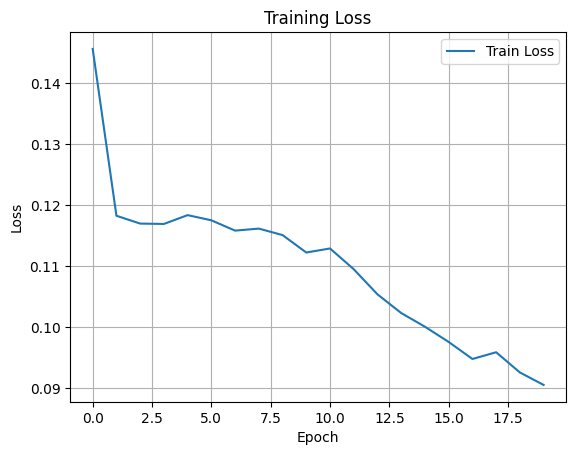

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()


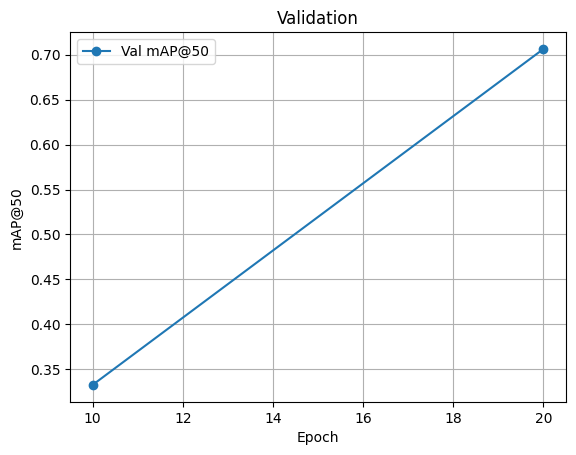

In [49]:
epochs_map = list(range(10, 10 * (len(history["val_map"]) + 1), 10))

plt.figure()
plt.plot(epochs_map, history["val_map"], marker="o", label="Val mAP@50")
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("Validation")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
import random
import torchvision.transforms.functional as F
from PIL import ImageDraw

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=4, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices):
        img, _ = dataset[idx]
        img_tensor = img.to(device)
        output = model([img_tensor])[0]

        img_pil = F.to_pil_image(img)
        draw = ImageDraw.Draw(img_pil)

        for box, score, label in zip(
            output["boxes"], output["scores"], output["labels"]
        ):
            if score < score_thresh:
                continue

            x1, y1, x2, y2 = box.cpu().numpy()
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
            draw.text((x1, y1), f"C{label.item()} {score:.2f}", fill="red")

        plt.subplot(2, 2, i + 1)
        plt.imshow(img_pil)
        plt.axis("off")

    plt.suptitle("Model Predictions on Test Data")
    plt.show()


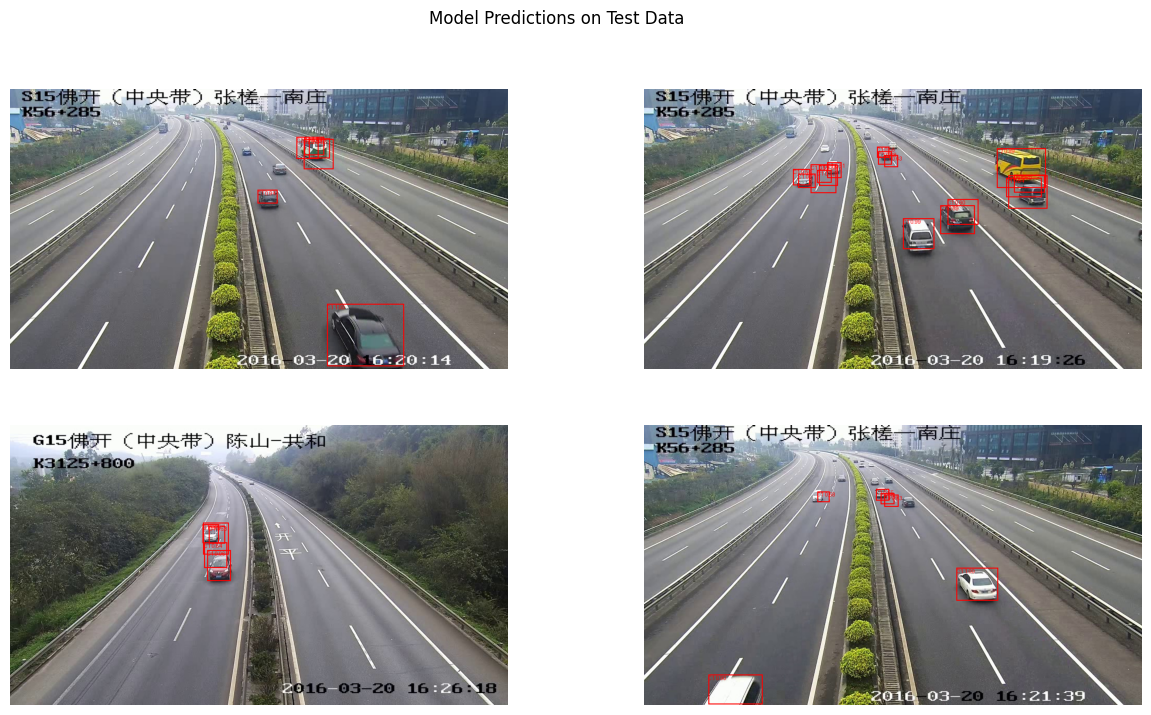

In [41]:
visualize_predictions(model, test_dataset, device)


In [45]:
test_loader = DataLoader(test_dataset, 8,
                                 shuffle=False, collate_fn=collate_fn)


In [47]:
final_test_map  = compute_map50(model, test_loader, device)
print(f"Final Test mAP@50: {final_test_map:.4f}")


Final Test mAP@50: 0.6549
